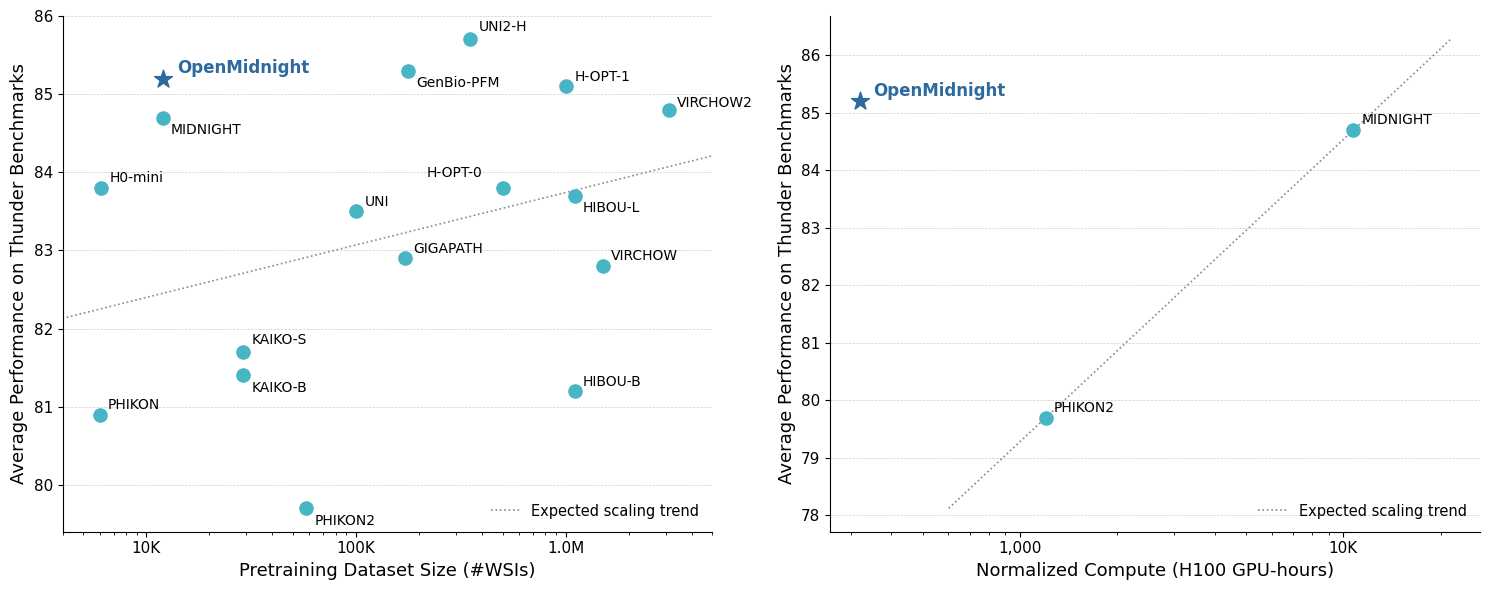

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ============================================================
# DATA — dataset size plot
# Format: 'Model': (x_value, performance, (label_dx, label_dy))
# label offset is per-point so overlapping labels can be nudged apart manually
# ============================================================
models_size = {
    'UNI2-H':     (350_000,   85.7, (6, 6)),
    'GenBio-PFM': (177_000,   85.3, (6, -12)),
    'H-OPT-1':    (1_000_000, 85.1, (6, 4)),
    'VIRCHOW2':   (3_100_000, 84.8, (6, 2)),
    'MIDNIGHT':   (12_000,    84.7, (6, -12)),
    'H-OPT-0':    (500_000,   83.8, (-55, 8)),
    'H0-mini':    (6_093,     83.8, (6, 4)),
    'HIBOU-L':    (1_100_000, 83.7, (6, -12)),
    'UNI':        (100_000,   83.5, (6, 4)),
    'GIGAPATH':   (171_189,   82.9, (6, 4)),
    'VIRCHOW':    (1_500_000, 82.8, (6, 4)),
    'KAIKO-S':    (29_000,    81.7, (6, 6)),
    'KAIKO-B':    (29_000,    81.4, (6, -12)),
    'HIBOU-B':    (1_100_000, 81.2, (6, 4)),
    'PHIKON':     (6_000,     80.9, (6, 4)),
    'PHIKON2':    (58_000,    79.7, (6, -12)),
}
our_model_size = {'OpenMidnight': (12_000, 85.2, (10, 4))}

# ============================================================
# DATA — compute plot
# ============================================================
models_compute = {
    'MIDNIGHT': (10_752, 84.7, (6, 4)),
    'PHIKON2':  (1_200,  79.7, (6, 4)),   # TODO: verify source
}
our_model_compute = {'OpenMidnight': (319, 85.2, (10, 4))}

# ============================================================
# Colors
# ============================================================
COLOR_OURS   = '#2D6A9F'
COLOR_OTHERS = '#48B5C4'

# ============================================================
# Shared plotting function
# ============================================================
def plot_panel(ax, models, our_model, xlabel):
    for name, (x, perf, (dx, dy)) in models.items():
        ax.scatter(x, perf, color=COLOR_OTHERS, s=90, zorder=3)
        ax.annotate(name, (x, perf), textcoords='offset points',
                    xytext=(dx, dy), fontsize=10, color='black')

    for name, (x, perf, (dx, dy)) in our_model.items():
        ax.scatter(x, perf, color=COLOR_OURS, s=180, zorder=5, marker='*')
        ax.annotate(name, (x, perf), textcoords='offset points',
                     xytext=(dx, dy), fontsize=12, fontweight='bold', color=COLOR_OURS)

    all_x = np.array([v[0] for v in models.values()])
    all_y = np.array([v[1] for v in models.values()])
    log_x = np.log10(all_x)
    coeffs = np.polyfit(log_x, all_y, 1)
    x_line = np.logspace(np.log10(min(all_x)) - 0.3,
                          np.log10(max(all_x)) + 0.3, 200)
    y_line = coeffs[0] * np.log10(x_line) + coeffs[1]
    ax.plot(x_line, y_line, linestyle=':', linewidth=1.2,
            color='#888888', zorder=1, label='Expected scaling trend')

    ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray')
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=10.5, frameon=False, loc='lower right')

# ============================================================
# Build combined figure
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.subplots_adjust(wspace=0.28)

plot_panel(ax1, models_size, our_model_size, 'Pretraining Dataset Size (#WSIs)')
ax1.set_ylabel('Average Performance on Thunder Benchmarks', fontsize=13)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}K' if x < 1_000_000 else f'{x/1_000_000:.1f}M'))
ax1.set_xlim(4_000, 5_000_000)

plot_panel(ax2, models_compute, our_model_compute, 'Normalized Compute (H100 GPU-hours)')
ax2.set_ylabel('Average Performance on Thunder Benchmarks', fontsize=13)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x):,}' if x < 10_000 else f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig('perf_dataset_compute.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
import wandb
api = wandb.Api()
run = api.run("sagarigrandhi_org/tcga-finetuning/z8g5diek")
runtime_seconds = run.summary.get("_runtime")
print(f"Runtime: {runtime_seconds / 3600:.2f} hours")
print(f"GPU-hours (8 GPUs): {runtime_seconds / 3600 * 8:.2f}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /admin/home/ratna/.netrc.


Runtime: 39.87 hours
GPU-hours (8 GPUs): 318.96
